# DS@GT StockTron Trading Performance Analysis

Comprehensive analysis of DS@GT StockTron AI trading strategy results from SQLite database.

**Analysis Date**: March 1, 2026  
**Experiment**: tesla_btc_baseline_risk (risk-managed paper portfolio)

## 1. Setup

In [8]:
import sys
import os
import json
import importlib
from pathlib import Path
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl

project_root = Path().absolute().parent  # notebooks/ -> project root
decision_making_dir = project_root / "decision_making"

sys.path.insert(0, str(project_root))
sys.path.insert(0, str(decision_making_dir))

os.chdir(decision_making_dir)

import decision_making.analysis.performance as perf_module
import decision_making.analysis.queries as query_module

importlib.reload(perf_module)
importlib.reload(query_module)

from decision_making.analysis.performance import (
    calculate_annualized_return,
    calculate_buy_hold_benchmark,
    calculate_max_drawdown,
    calculate_portfolio_benchmark,
    calculate_realized_pnl,
    calculate_sharpe_ratio,
    extract_ticker_positions,
)
from decision_making.analysis.queries import (
    check_data_quality,
    get_all_decisions,
    get_all_signals,
    get_decision_summary,
    get_experiment_metadata,
    get_portfolio_timeseries,
    get_signal_summary,
)
from decision_making.database.sqlite_helper import SQLiteDB

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"] = 10

COLORS = {
    "TSLA": "#E31E24",
    "BTC": "#F7931A",
    "portfolio": "#2E86AB",
    "benchmark": "#A23B72",
    "buy": "#28A745",
    "sell": "#DC3545",
    "hold": "#6C757D",
    "bullish": "#90EE90",
    "bearish": "#F08080",
    "neutral": "#FFE4B5",
}

print("Setup complete!")
print(f"Working directory: {os.getcwd()}")

Setup complete!
Working directory: /Users/maximilianheil/OMSCS/finmmeval-task3-2026 copy/decision_making


## 2. Load Data from Database

In [9]:
config_name = "tesla_btc_baseline_risk"

# Initialize database connection
db = SQLiteDB()
config_id = db.get_config_id_by_name(config_name)

if not config_id:
    raise ValueError(f"Configuration '{config_name}' not found in database")

print(f"Config ID: {config_id}")

Config ID: e37751ec-31fb-4cae-85a2-c24c127a34a5


In [10]:
# Check data quality
data_quality = check_data_quality(db, config_id)
print("=" * 60)
print("DATA QUALITY CHECK")
print("=" * 60)
print(f"Trading days  : {data_quality['trading_days']}")
print(f"Total decisions: {data_quality['total_decisions']}")
print(f"Total signals : {data_quality['total_signals']}")
print(f"First date    : {data_quality['first_date']}")
print(f"Last date     : {data_quality['last_date']}")
print("=" * 60)

# Load experiment metadata
metadata = get_experiment_metadata(db, config_id)

print("\nEXPERIMENT METADATA")
print("=" * 60)
print(f"Experiment Name: {metadata['exp_name']}")
print(f"Tickers        : {metadata['tickers']}")
print(f"LLM Model      : {metadata['llm_model']}")
print(f"LLM Provider   : {metadata['llm_provider']}")
print(f"Has Planner    : {metadata['has_planner']}")
print(f"Start Date     : {metadata['start_date'].strftime('%Y-%m-%d') if metadata['start_date'] else 'N/A'}")
print(f"End Date       : {metadata['end_date'].strftime('%Y-%m-%d') if metadata['end_date'] else 'N/A'}")
print(f"Trading Days   : {metadata['trading_days']}")
print("=" * 60)

start_date = metadata["start_date"]
end_date = metadata["end_date"]
tickers = json.loads(metadata["tickers"]) if isinstance(metadata["tickers"], str) else metadata["tickers"]

DATA QUALITY CHECK
Trading days  : 362
Total decisions: 722
Total signals : 1441
First date    : 2024-08-02T00:00:00
Last date     : 2026-01-09T00:00:00

EXPERIMENT METADATA
Experiment Name: tesla_btc_baseline_risk
Tickers        : ["TSLA", "BTC"]
LLM Model      : gpt-4.1-nano
LLM Provider   : OpenAI
Has Planner    : False
Start Date     : 2024-08-02
End Date       : 2026-01-09
Trading Days   : 526


In [11]:
# Load portfolio timeseries (includes daily_return_pct and cumulative_return_pct)
portfolio_df = get_portfolio_timeseries(db, config_id)
print(f"Loaded {len(portfolio_df)} portfolio snapshots")
print(f"\nColumns: {portfolio_df.columns}")
print("\nFirst few rows:")
portfolio_df.head()

Loaded 362 portfolio snapshots

Columns: ['trading_date', 'cashflow', 'total_assets', 'positions', 'daily_return_pct', 'cumulative_return_pct']

First few rows:


trading_date,cashflow,total_assets,positions,daily_return_pct,cumulative_return_pct
datetime[μs],f64,f64,str,f64,f64
2024-08-02 00:00:00,100000.0,100000.0,"""{}""",null,0.0
2024-08-02 00:00:00,95012.22,100000.0,"""{""TSLA"": {""value"": 4987.78, ""s…",0.0,0.0
2024-08-05 00:00:00,95219.89,99788.63,"""{""TSLA"": {""value"": 4568.74, ""s…",-0.21137,-0.21137
2024-08-06 00:00:00,95219.89,99595.25,"""{""TSLA"": {""value"": 4375.36, ""s…",-0.19379,-0.40475
2024-08-07 00:00:00,95219.89,99633.97,"""{""TSLA"": {""value"": 4414.08, ""s…",0.038877,-0.36603


In [12]:
# Load trading decisions
decisions_df = get_all_decisions(db, config_id)
print(f"Loaded {len(decisions_df)} trading decisions")
print(f"\nDecision breakdown:")
print(decisions_df.group_by("action").agg(pl.count()).sort("action"))

Loaded 722 trading decisions

Decision breakdown:
shape: (3, 2)
┌────────┬───────┐
│ action ┆ count │
│ ---    ┆ ---   │
│ str    ┆ u32   │
╞════════╪═══════╡
│ Buy    ┆ 55    │
│ Hold   ┆ 623   │
│ Sell   ┆ 44    │
└────────┴───────┘


/var/folders/88/k8_9k44n1z56qcbp51nv8kk80000gn/T/ipykernel_45388/1867048594.py:5: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  print(decisions_df.group_by("action").agg(pl.count()).sort("action"))


In [13]:
# Load analyst signals
signals_df = get_all_signals(db, config_id)
print(f"Loaded {len(signals_df)} analyst signals")
print(f"\nSignal breakdown:")
print(signals_df.group_by(["analyst", "signal"]).agg(pl.count()).sort(["analyst", "signal"]))

Loaded 1441 analyst signals

Signal breakdown:
shape: (6, 3)
┌──────────────┬─────────┬───────┐
│ analyst      ┆ signal  ┆ count │
│ ---          ┆ ---     ┆ ---   │
│ str          ┆ str     ┆ u32   │
╞══════════════╪═════════╪═══════╡
│ company_news ┆ Bearish ┆ 77    │
│ company_news ┆ Bullish ┆ 198   │
│ company_news ┆ Neutral ┆ 444   │
│ technical    ┆ Bearish ┆ 199   │
│ technical    ┆ Bullish ┆ 370   │
│ technical    ┆ Neutral ┆ 153   │
└──────────────┴─────────┴───────┘


/var/folders/88/k8_9k44n1z56qcbp51nv8kk80000gn/T/ipykernel_45388/3000880721.py:5: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  print(signals_df.group_by(["analyst", "signal"]).agg(pl.count()).sort(["analyst", "signal"]))


## 3. Portfolio Performance Analysis

In [14]:
# Calculate key metrics
initial_value = portfolio_df["total_assets"][0]
final_value = portfolio_df["total_assets"][-1]
total_return_pct = ((final_value - initial_value) / initial_value) * 100
num_days = (end_date - start_date).days
annualized_return = calculate_annualized_return(total_return_pct, num_days)

# Calculate Sharpe ratio
returns_series = portfolio_df["daily_return_pct"]
sharpe = calculate_sharpe_ratio(returns_series)

# Calculate max drawdown
max_dd, peak_idx, trough_idx = calculate_max_drawdown(portfolio_df["total_assets"])

# Print metrics
print("=" * 60)
print("PORTFOLIO PERFORMANCE METRICS")
print("=" * 60)
print(f"Initial Portfolio Value: ${initial_value:,.2f}")
print(f"Final Portfolio Value: ${final_value:,.2f}")
print(f"\nTotal Return: {total_return_pct:.2f}%")
print(f"Annualized Return: {annualized_return:.2f}%")
print(f"\nSharpe Ratio: {sharpe:.3f}")
print(f"Maximum Drawdown: {max_dd:.2f}%")
print(f"\nNumber of Trading Days: {num_days}")
print(f"Average Daily Return: {returns_series.drop_nulls().mean():.3f}%")
print(f"Daily Return Volatility: {returns_series.drop_nulls().std():.3f}%")
print("=" * 60)

PORTFOLIO PERFORMANCE METRICS
Initial Portfolio Value: $100,000.00
Final Portfolio Value: $92,919.52

Total Return: -7.08%
Annualized Return: -4.98%

Sharpe Ratio: 0.026
Maximum Drawdown: -33.37%

Number of Trading Days: 525
Average Daily Return: 0.003%
Daily Return Volatility: 2.144%


### 3.1 Portfolio Value Over Time

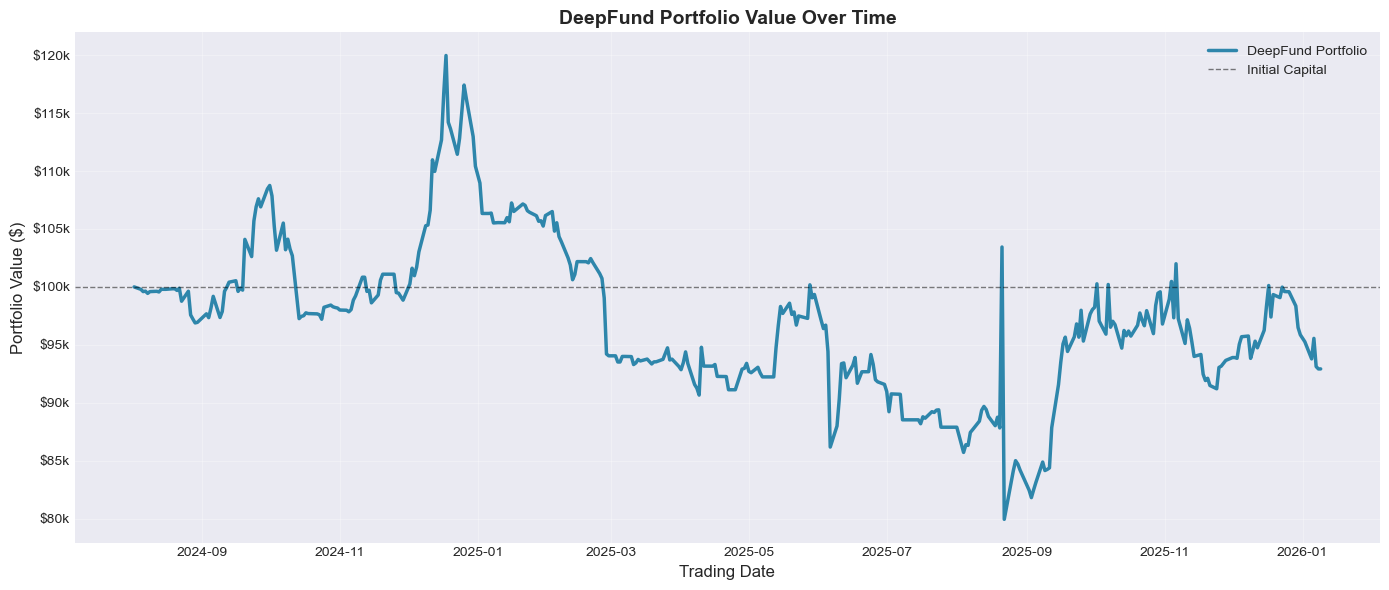

In [15]:
fig, ax = plt.subplots(figsize=(14, 6))

# Convert to pandas for easier plotting
plot_df = portfolio_df.to_pandas()

# Plot portfolio value
ax.plot(
    plot_df["trading_date"],
    plot_df["total_assets"],
    linewidth=2.5,
    color=COLORS["portfolio"],
    label="DS@GT StockTron Portfolio",
)

# Add initial capital baseline
ax.axhline(initial_value, color="black", linestyle="--", linewidth=1, alpha=0.5, label="Initial Capital")

# Formatting
ax.set_title("DS@GT StockTron Portfolio Value Over Time", fontsize=14, fontweight="bold")
ax.set_xlabel("Trading Date", fontsize=12)
ax.set_ylabel("Portfolio Value ($)", fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Format y-axis as currency
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x / 1000:.0f}k"))

plt.tight_layout()
plt.show()

### 3.2 Cumulative Returns

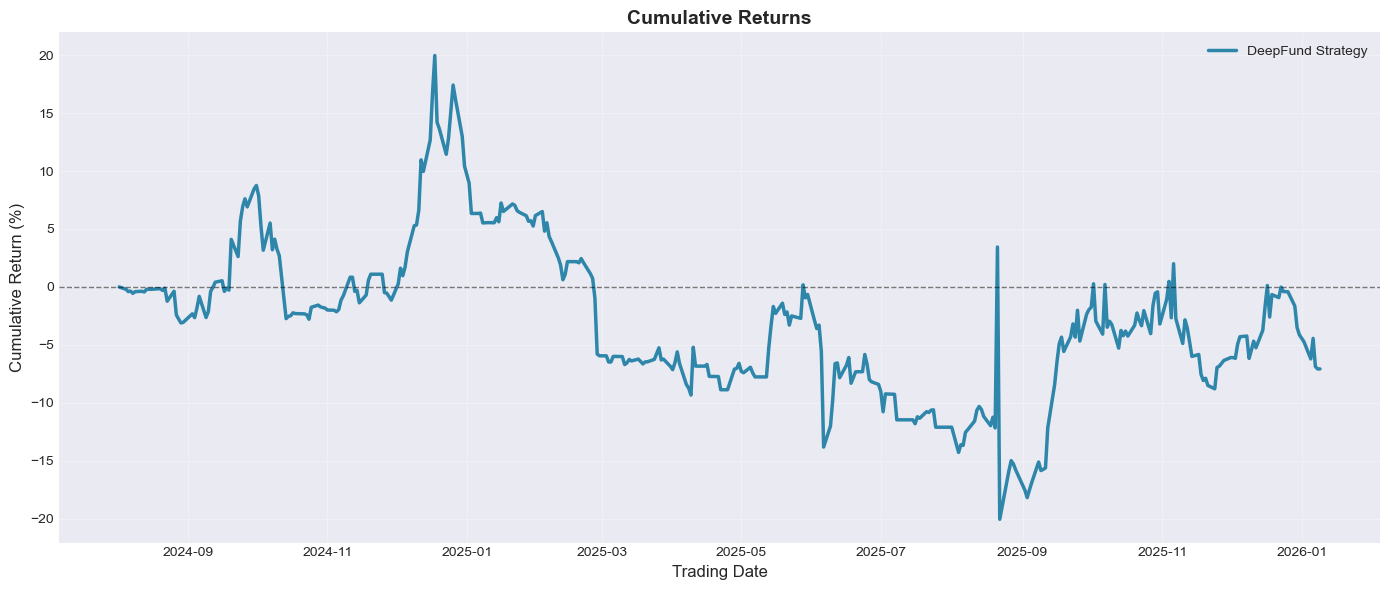

In [16]:
fig, ax = plt.subplots(figsize=(14, 6))

plot_df = portfolio_df.to_pandas()

ax.plot(
    plot_df["trading_date"],
    plot_df["cumulative_return_pct"],
    linewidth=2.5,
    color=COLORS["portfolio"],
    label="DS@GT StockTron Strategy",
)

# Add zero baseline
ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.5)

# Formatting
ax.set_title("Cumulative Returns", fontsize=14, fontweight="bold")
ax.set_xlabel("Trading Date", fontsize=12)
ax.set_ylabel("Cumulative Return (%)", fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 3.3 Daily Returns Distribution

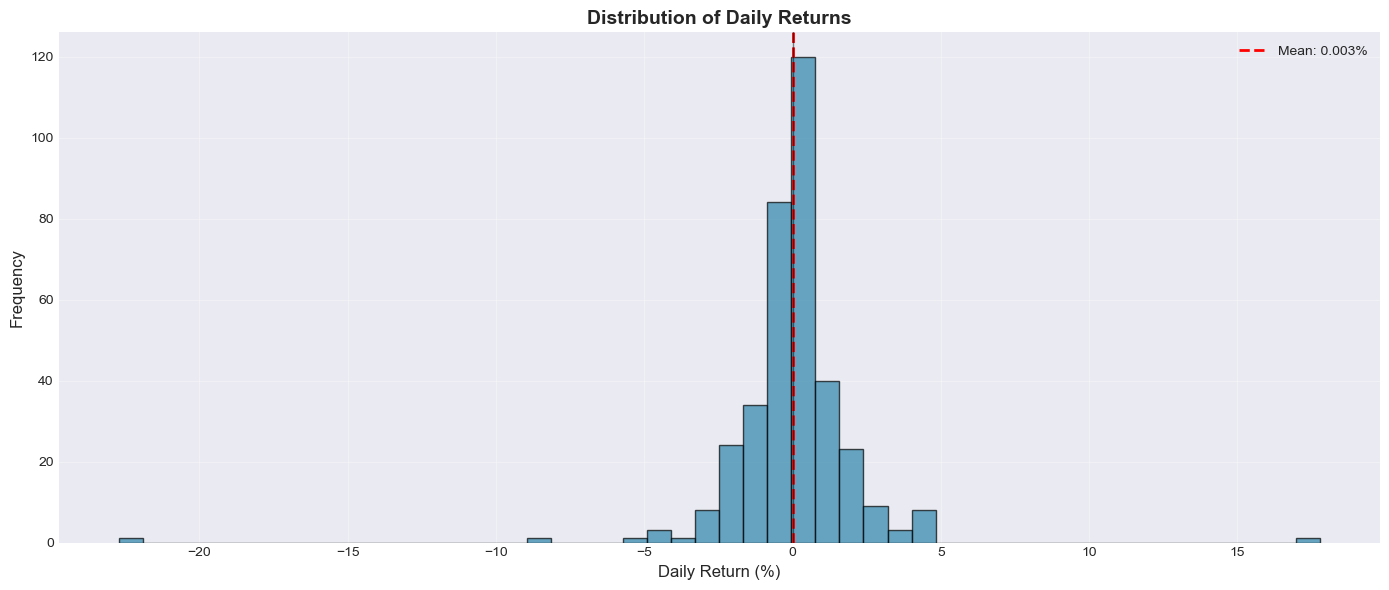

In [17]:
fig, ax = plt.subplots(figsize=(14, 6))

# Get clean returns (drop nulls)
returns_clean = portfolio_df["daily_return_pct"].drop_nulls().to_numpy()

# Plot histogram
ax.hist(returns_clean, bins=50, color=COLORS["portfolio"], alpha=0.7, edgecolor="black")

# Add mean line
mean_return = np.mean(returns_clean)
ax.axvline(mean_return, color="red", linestyle="--", linewidth=2, label=f"Mean: {mean_return:.3f}%")

# Add zero line
ax.axvline(0, color="black", linestyle="-", linewidth=1, alpha=0.5)

# Formatting
ax.set_title("Distribution of Daily Returns", fontsize=14, fontweight="bold")
ax.set_xlabel("Daily Return (%)", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 3.4 Drawdown Analysis

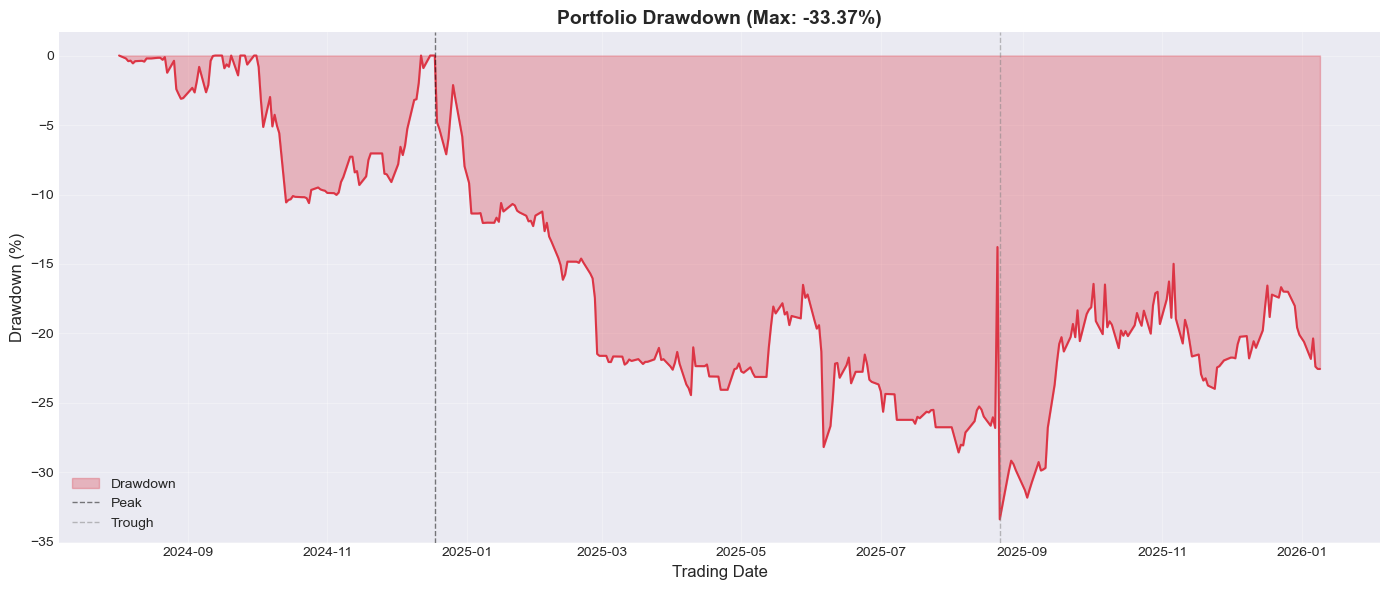

In [18]:
# Calculate drawdown series
values = portfolio_df["total_assets"].to_numpy()
running_max = np.maximum.accumulate(values)
drawdown = (values - running_max) / running_max * 100

fig, ax = plt.subplots(figsize=(14, 6))

plot_df = portfolio_df.to_pandas()
plot_df["drawdown"] = drawdown

# Plot drawdown
ax.fill_between(
    plot_df["trading_date"],
    drawdown,
    0,
    color=COLORS["sell"],
    alpha=0.3,
    label="Drawdown",
)
ax.plot(plot_df["trading_date"], drawdown, color=COLORS["sell"], linewidth=1.5)

# Highlight maximum drawdown period
if peak_idx is not None and trough_idx is not None:
    ax.axvline(
        plot_df["trading_date"].iloc[peak_idx],
        color="black",
        linestyle="--",
        linewidth=1,
        alpha=0.5,
        label="Peak",
    )
    ax.axvline(
        plot_df["trading_date"].iloc[trough_idx],
        color="gray",
        linestyle="--",
        linewidth=1,
        alpha=0.5,
        label="Trough",
    )

# Formatting
ax.set_title(f"Portfolio Drawdown (Max: {max_dd:.2f}%)", fontsize=14, fontweight="bold")
ax.set_xlabel("Trading Date", fontsize=12)
ax.set_ylabel("Drawdown (%)", fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 3.5 Position Breakdown Over Time

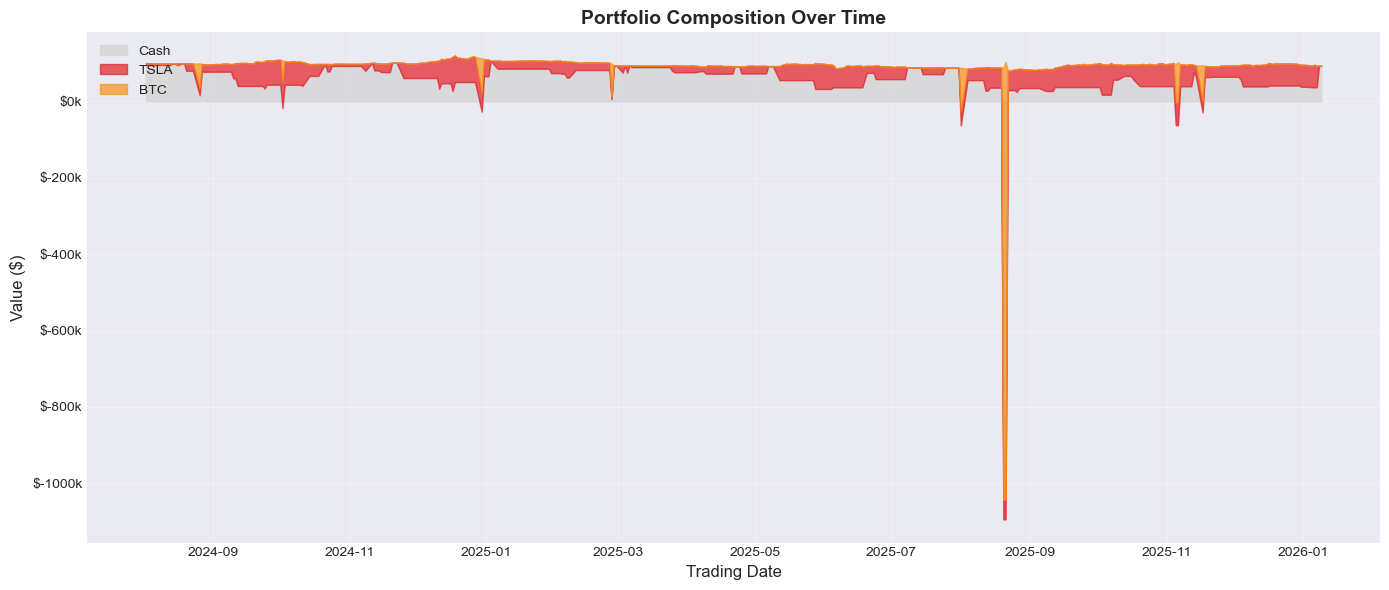

In [19]:
# Extract ticker positions from the positions JSON column
tsla_positions = extract_ticker_positions(portfolio_df, "TSLA")
btc_positions = extract_ticker_positions(portfolio_df, "BTC")

# Prepare data for stacked area plot
plot_df = portfolio_df.select(["trading_date", "cashflow"]).to_pandas()
plot_df["TSLA_value"] = tsla_positions["value"].to_pandas()
plot_df["BTC_value"] = btc_positions["value"].to_pandas()

fig, ax = plt.subplots(figsize=(14, 6))

ax.fill_between(plot_df["trading_date"], 0, plot_df["cashflow"], color="lightgray", alpha=0.7, label="Cash")
ax.fill_between(
    plot_df["trading_date"],
    plot_df["cashflow"],
    plot_df["cashflow"] + plot_df["TSLA_value"],
    color=COLORS["TSLA"],
    alpha=0.7,
    label="TSLA",
)
ax.fill_between(
    plot_df["trading_date"],
    plot_df["cashflow"] + plot_df["TSLA_value"],
    plot_df["cashflow"] + plot_df["TSLA_value"] + plot_df["BTC_value"],
    color=COLORS["BTC"],
    alpha=0.7,
    label="BTC",
)

ax.set_title("Portfolio Composition Over Time", fontsize=14, fontweight="bold")
ax.set_xlabel("Trading Date", fontsize=12)
ax.set_ylabel("Value ($)", fontsize=12)
ax.legend(fontsize=10, loc="upper left")
ax.grid(alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x / 1000:.0f}k"))

plt.tight_layout()
plt.show()

### 3.6 Normalized Trading Performance (1-Share Assumption)

This section calculates cumulative returns by **treating every trade as buying/selling exactly 1 share**, regardless of actual position sizes.

**How it works:**
- **Buy**: Cash outflow = -price (buy 1 share)
- **Sell**: Cash inflow = +price (sell 1 share)  
- **Hold**: No cash flow = 0
- **Cumulative**: Running sum of normalized cash flows

**Purpose:**
This removes position sizing effects and focuses purely on **price timing quality**. It shows whether the strategy is buying at good prices and selling at better prices, independent of how many shares are traded.

**Key Difference:**
- **Portfolio Value**: Actual capital deployed with real position sizes
- **Normalized Performance**: Every trade treated as 1 share to evaluate timing

In [20]:
# Calculate normalized P&L (1-share per trade assumption)
try:
    realized_pnl_df = calculate_realized_pnl(decisions_df, initial_capital=initial_value)

    print(f"✓ Successfully calculated normalized P&L for {len(realized_pnl_df)} trading decisions")
    print(f"\nBuy decisions: {len(realized_pnl_df.filter(pl.col('action') == 'Buy'))}")
    print(f"Sell decisions: {len(realized_pnl_df.filter(pl.col('action') == 'Sell'))}")
    print(f"Hold decisions: {len(realized_pnl_df.filter(pl.col('action') == 'Hold'))}")

    # Calculate totals
    total_spent = -realized_pnl_df.filter(pl.col("cashflow") < 0)["cashflow"].sum()
    total_received = realized_pnl_df.filter(pl.col("cashflow") > 0)["cashflow"].sum()
    net_pnl = realized_pnl_df["cashflow"].sum()
    final_cumulative = realized_pnl_df["cumulative_cashflow"][-1]
    final_return_pct = realized_pnl_df["cumulative_return_pct"][-1]

    print(f"\nTotal Spent (buys): ${total_spent:,.2f}")
    print(f"Total Received (sells): ${total_received:,.2f}")
    print(f"Net Normalized P&L: ${net_pnl:,.2f}")
    print(f"Final Cumulative: ${final_cumulative:,.2f}")
    print(f"Normalized Return: {final_return_pct:.2f}%")

    # Show price ranges for buys and sells
    print("\n" + "=" * 60)
    print("Price Analysis:")
    print("=" * 60)
    buys = realized_pnl_df.filter(pl.col("action") == "Buy")
    sells = realized_pnl_df.filter(pl.col("action") == "Sell")

    if len(buys) > 0:
        avg_buy_price = buys["price"].mean()
        print(f"Average Buy Price: ${avg_buy_price:.2f}")
        print(f"Buy Price Range: ${buys['price'].min():.2f} - ${buys['price'].max():.2f}")

    if len(sells) > 0:
        avg_sell_price = sells["price"].mean()
        print(f"Average Sell Price: ${avg_sell_price:.2f}")
        print(f"Sell Price Range: ${sells['price'].min():.2f} - ${sells['price'].max():.2f}")

    if len(buys) > 0 and len(sells) > 0:
        avg_spread = avg_sell_price - avg_buy_price
        spread_pct = avg_spread / avg_buy_price * 100
        print(f"\nAverage Sell-Buy Spread: ${avg_spread:.2f} ({spread_pct:.2f}%)")

except Exception as e:
    print(f"ERROR calculating normalized P&L: {e}")
    import traceback

    traceback.print_exc()
    raise

✓ Successfully calculated normalized P&L for 722 trading decisions

Buy decisions: 55
Sell decisions: 44
Hold decisions: 623

Total Spent (buys): $894,030.60
Total Received (sells): $732,221.55
Net Normalized P&L: $-161,809.05
Final Cumulative: $-161,809.05
Normalized Return: -161.81%

Price Analysis:
Average Buy Price: $16255.10
Buy Price Range: $209.21 - $115660.09
Average Sell Price: $16641.40
Sell Price Range: $205.75 - $114126.62

Average Sell-Buy Spread: $386.30 (2.38%)


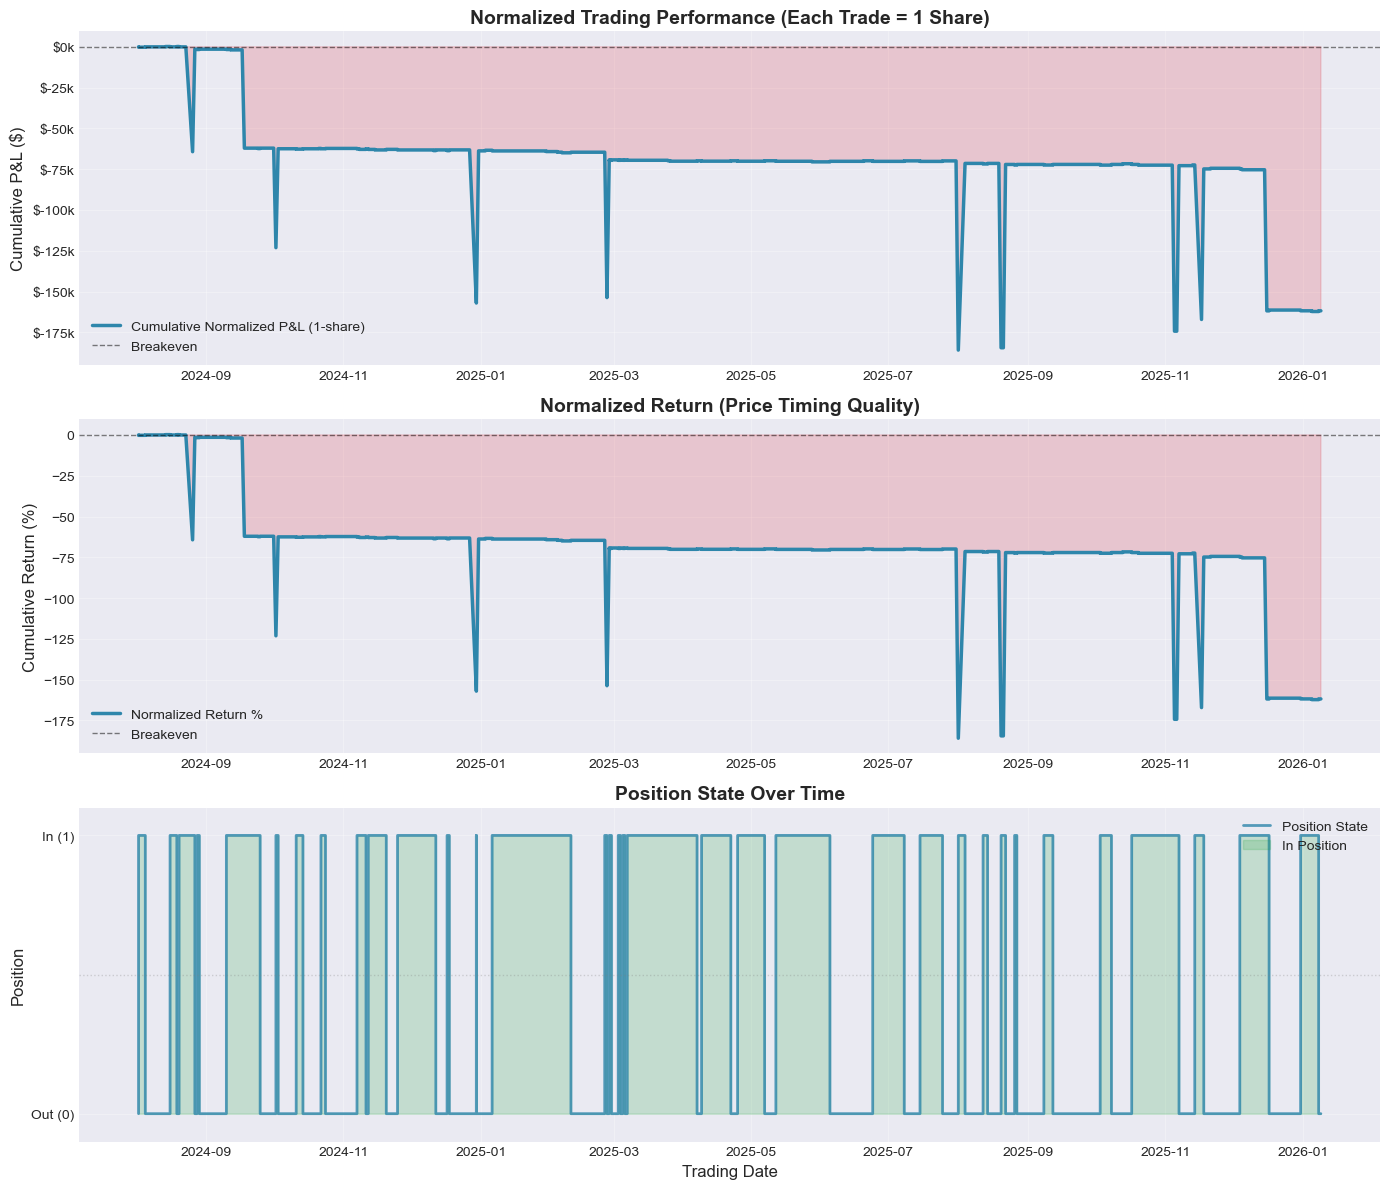

In [21]:
# Plot normalized cumulative performance (1-share trades)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12))

plot_df = realized_pnl_df.to_pandas()

# Create position state indicator (0 or 1, Hold maintains previous state)
position_state = []
current_state = 0  # Start with no position

for action in plot_df["action"]:
    if action == "Buy":
        current_state = 1  # Enter position
    elif action == "Sell":
        current_state = 0  # Exit position
    # Hold: keep current_state as is
    position_state.append(current_state)

plot_df["position_state"] = position_state

# Top panel: Cumulative normalized P&L in dollars
ax1.plot(
    plot_df["trading_date"],
    plot_df["cumulative_cashflow"],
    linewidth=2.5,
    color=COLORS["portfolio"],
    label="Cumulative Normalized P&L (1-share)",
)
ax1.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.5, label="Breakeven")
ax1.fill_between(
    plot_df["trading_date"],
    0,
    plot_df["cumulative_cashflow"],
    where=(plot_df["cumulative_cashflow"] >= 0),
    color=COLORS["buy"],
    alpha=0.2,
)
ax1.fill_between(
    plot_df["trading_date"],
    0,
    plot_df["cumulative_cashflow"],
    where=(plot_df["cumulative_cashflow"] < 0),
    color=COLORS["sell"],
    alpha=0.2,
)

ax1.set_title("Normalized Trading Performance (Each Trade = 1 Share)", fontsize=14, fontweight="bold")
ax1.set_ylabel("Cumulative P&L ($)", fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x / 1000:.0f}k"))

# Middle panel: Normalized return as percentage
ax2.plot(
    plot_df["trading_date"],
    plot_df["cumulative_return_pct"],
    linewidth=2.5,
    color=COLORS["portfolio"],
    label="Normalized Return %",
)
ax2.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.5, label="Breakeven")
ax2.fill_between(
    plot_df["trading_date"],
    0,
    plot_df["cumulative_return_pct"],
    where=(plot_df["cumulative_return_pct"] >= 0),
    color=COLORS["buy"],
    alpha=0.2,
)
ax2.fill_between(
    plot_df["trading_date"],
    0,
    plot_df["cumulative_return_pct"],
    where=(plot_df["cumulative_return_pct"] < 0),
    color=COLORS["sell"],
    alpha=0.2,
)

ax2.set_title("Normalized Return (Price Timing Quality)", fontsize=14, fontweight="bold")
ax2.set_ylabel("Cumulative Return (%)", fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

# Bottom panel: Position state (1=in market, 0=out of market)
ax3.plot(
    plot_df["trading_date"],
    plot_df["position_state"],
    linewidth=2,
    color=COLORS["portfolio"],
    alpha=0.8,
    drawstyle="steps-post",  # Step function for cleaner transitions
    label="Position State",
)

# Fill the "in market" (1) regions
ax3.fill_between(
    plot_df["trading_date"], 0, plot_df["position_state"], color=COLORS["buy"], alpha=0.2, step="post", label="In Position"
)

# Reference lines
ax3.axhline(0.5, color="gray", linestyle=":", linewidth=1, alpha=0.3)

ax3.set_title("Position State Over Time", fontsize=14, fontweight="bold")
ax3.set_xlabel("Trading Date", fontsize=12)
ax3.set_ylabel("Position", fontsize=12)
ax3.set_yticks([0, 1])
ax3.set_yticklabels(["Out (0)", "In (1)"])
ax3.legend(fontsize=10, loc="upper right")
ax3.grid(alpha=0.3)
ax3.set_ylim(-0.1, 1.1)

plt.tight_layout()
plt.show()

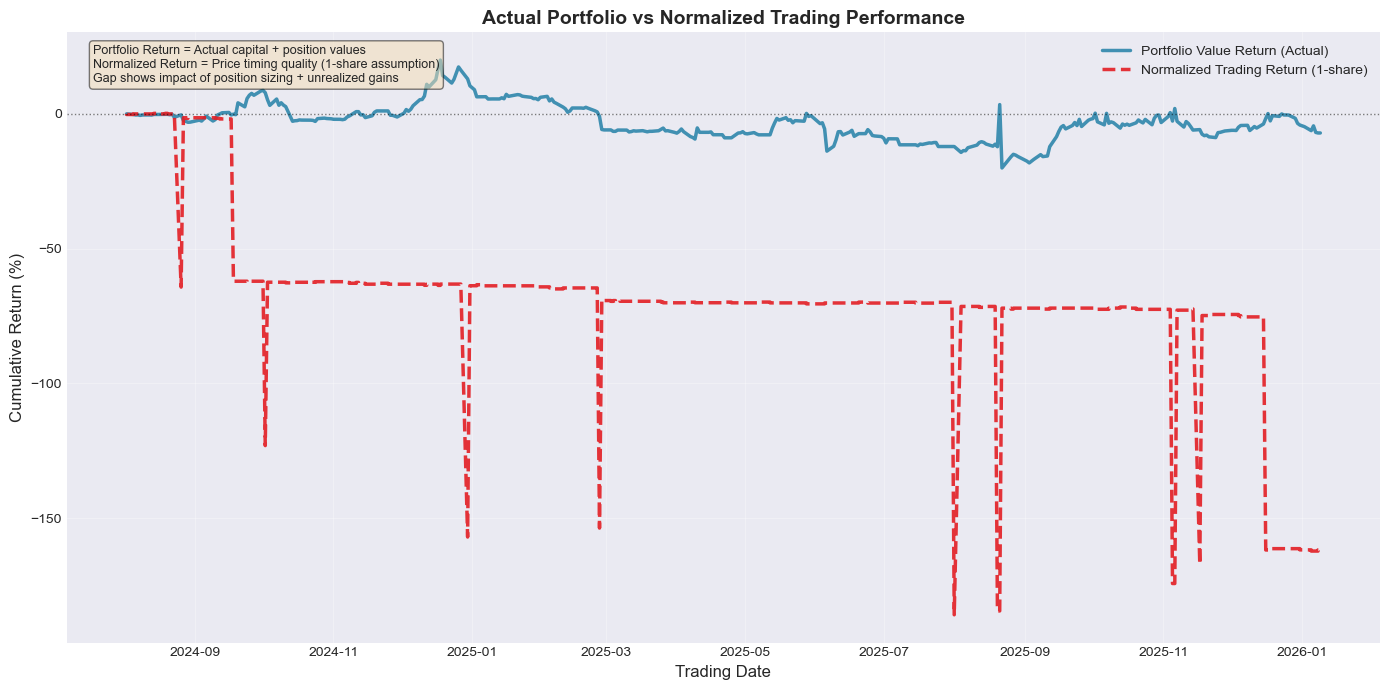


PERFORMANCE COMPARISON
Actual Portfolio Return:     -7.08%
Normalized Trading Return:   -161.81%

The actual portfolio return of -7.08% includes:
- Position sizing effects (how many shares traded)
- Unrealized gains from currently held positions

The normalized return of -161.81% shows:
- Pure price timing quality (buying low, selling high)
- Independent of position sizes or holdings


In [22]:
# Compare Portfolio Value vs Normalized Trading Performance
fig, ax = plt.subplots(figsize=(14, 7))

# Check if realized_pnl_df exists (should be created in Cell 22)
try:
    # Align data on trading_date by merging
    # portfolio_df has 528 rows (includes initial state)
    # realized_pnl_df has 527 rows (one per decision)
    # We'll plot them separately since they represent different things

    # Plot portfolio value cumulative return (actual performance with position sizing)
    portfolio_plot = portfolio_df.to_pandas()
    ax.plot(
        portfolio_plot["trading_date"],
        portfolio_plot["cumulative_return_pct"],
        linewidth=2.5,
        color=COLORS["portfolio"],
        label="Portfolio Value Return (Actual)",
        alpha=0.9,
    )

    # Plot normalized return (1-share trades, shows timing quality)
    normalized_plot = realized_pnl_df.to_pandas()
    ax.plot(
        normalized_plot["trading_date"],
        normalized_plot["cumulative_return_pct"],
        linewidth=2.5,
        color=COLORS["TSLA"],
        label="Normalized Trading Return (1-share)",
        linestyle="--",
        alpha=0.9,
    )

    # Add zero line
    ax.axhline(0, color="black", linestyle=":", linewidth=1, alpha=0.5)

    # Formatting
    ax.set_title("Actual Portfolio vs Normalized Trading Performance", fontsize=14, fontweight="bold")
    ax.set_xlabel("Trading Date", fontsize=12)
    ax.set_ylabel("Cumulative Return (%)", fontsize=12)
    ax.legend(fontsize=10, loc="best")
    ax.grid(alpha=0.3)

    # Add text box explaining the difference
    textstr = (
        "Portfolio Return = Actual capital + position values\n"
        "Normalized Return = Price timing quality (1-share assumption)\n"
        "Gap shows impact of position sizing + unrealized gains"
    )
    props = dict(boxstyle="round", facecolor="wheat", alpha=0.5)
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=9, verticalalignment="top", bbox=props)

    plt.tight_layout()
    plt.show()

    # Print summary comparison
    final_portfolio_return = portfolio_plot["cumulative_return_pct"].iloc[-1]
    final_normalized_return = normalized_plot["cumulative_return_pct"].iloc[-1]

    print("\n" + "=" * 60)
    print("PERFORMANCE COMPARISON")
    print("=" * 60)
    print(f"Actual Portfolio Return:     {final_portfolio_return:.2f}%")
    print(f"Normalized Trading Return:   {final_normalized_return:.2f}%")
    print("=" * 60)
    print(f"\nThe actual portfolio return of {final_portfolio_return:.2f}% includes:")
    print(f"- Position sizing effects (how many shares traded)")
    print(f"- Unrealized gains from currently held positions")
    print(f"\nThe normalized return of {final_normalized_return:.2f}% shows:")
    print(f"- Pure price timing quality (buying low, selling high)")
    print(f"- Independent of position sizes or holdings")

except NameError:
    print("ERROR: realized_pnl_df not found. Please run Cell 22 first to calculate normalized P&L.")
except Exception as e:
    print(f"ERROR creating comparison plot: {e}")
    import traceback

    traceback.print_exc()

## 4. Trading Decisions Analysis

### 4.1 Decision Distribution

In [23]:
# Get decision summary
decision_summary = get_decision_summary(db, config_id)
print("Decision Summary:")
print(decision_summary)

Decision Summary:
shape: (6, 4)
┌────────┬────────┬───────┬──────────────┐
│ ticker ┆ action ┆ count ┆ avg_price    │
│ ---    ┆ ---    ┆ ---   ┆ ---          │
│ str    ┆ str    ┆ i64   ┆ f64          │
╞════════╪════════╪═══════╪══════════════╡
│ BTC    ┆ Buy    ┆ 10    ┆ 87932.208    │
│ BTC    ┆ Hold   ┆ 343   ┆ 93750.052624 │
│ BTC    ┆ Sell   ┆ 8     ┆ 90079.13     │
│ TSLA   ┆ Buy    ┆ 45    ┆ 326.856001   │
│ TSLA   ┆ Hold   ┆ 280   ┆ 339.387643   │
│ TSLA   ┆ Sell   ┆ 36    ┆ 321.903055   │
└────────┴────────┴───────┴──────────────┘


/var/folders/88/k8_9k44n1z56qcbp51nv8kk80000gn/T/ipykernel_45388/178842164.py:5: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  action_counts = decisions_df.group_by("action").agg(pl.count()).to_pandas()
/var/folders/88/k8_9k44n1z56qcbp51nv8kk80000gn/T/ipykernel_45388/178842164.py:18: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  ticker_action = decisions_df.group_by(["ticker", "action"]).agg(pl.count()).to_pandas()


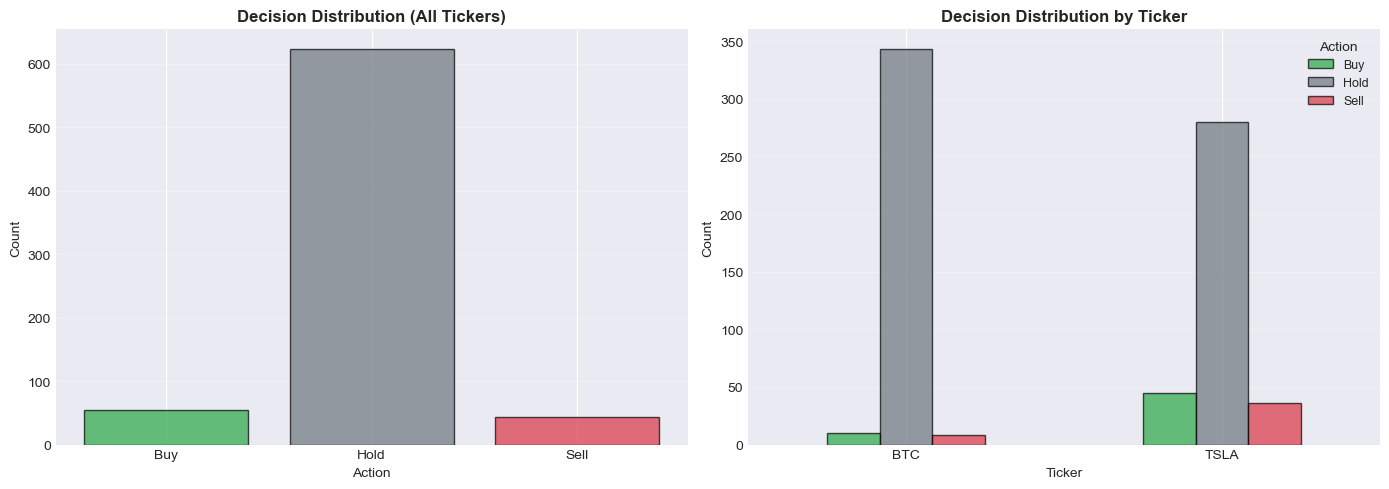

In [24]:
# Plot decision distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Count by action
action_counts = decisions_df.group_by("action").agg(pl.count()).to_pandas()
action_counts = action_counts.sort_values("action")

colors_map = {"Buy": COLORS["buy"], "Sell": COLORS["sell"], "Hold": COLORS["hold"]}
bar_colors = [colors_map.get(action, "gray") for action in action_counts["action"]]

ax1.bar(action_counts["action"], action_counts["count"], color=bar_colors, alpha=0.7, edgecolor="black")
ax1.set_title("Decision Distribution (All Tickers)", fontsize=12, fontweight="bold")
ax1.set_xlabel("Action", fontsize=10)
ax1.set_ylabel("Count", fontsize=10)
ax1.grid(alpha=0.3, axis="y")

# Count by ticker and action
ticker_action = decisions_df.group_by(["ticker", "action"]).agg(pl.count()).to_pandas()
ticker_action_pivot = ticker_action.pivot(index="ticker", columns="action", values="count").fillna(0)

ticker_action_pivot.plot(
    kind="bar",
    ax=ax2,
    color=[colors_map.get(col, "gray") for col in ticker_action_pivot.columns],
    alpha=0.7,
    edgecolor="black",
)
ax2.set_title("Decision Distribution by Ticker", fontsize=12, fontweight="bold")
ax2.set_xlabel("Ticker", fontsize=10)
ax2.set_ylabel("Count", fontsize=10)
ax2.legend(title="Action", fontsize=9)
ax2.grid(alpha=0.3, axis="y")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

### 4.2 Trading Timeline

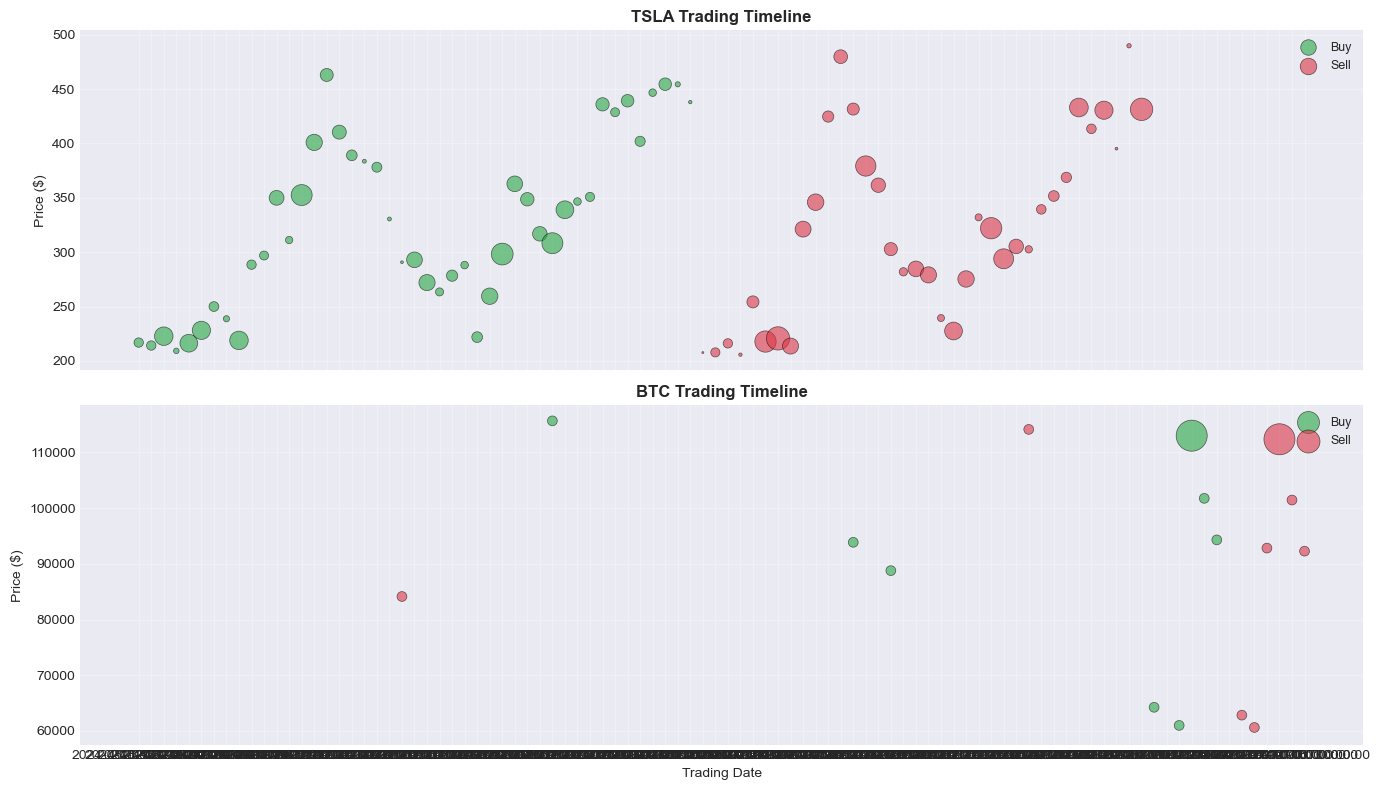

In [25]:
# Filter to just Buy and Sell (exclude Hold for clarity)
trades = decisions_df.filter(pl.col("action").is_in(["Buy", "Sell"])).to_pandas()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# TSLA trades
tsla_trades = trades[trades["ticker"] == "TSLA"]
for action in ["Buy", "Sell"]:
    action_trades = tsla_trades[tsla_trades["action"] == action]
    if len(action_trades) > 0:
        ax1.scatter(
            action_trades["trading_date"],
            action_trades["price"],
            s=action_trades["shares"] * 2,  # Size by shares
            color=colors_map[action],
            alpha=0.6,
            label=action,
            edgecolors="black",
            linewidth=0.5,
        )

ax1.set_title("TSLA Trading Timeline", fontsize=12, fontweight="bold")
ax1.set_ylabel("Price ($)", fontsize=10)
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# BTC trades
btc_trades = trades[trades["ticker"] == "BTC"]
for action in ["Buy", "Sell"]:
    action_trades = btc_trades[btc_trades["action"] == action]
    if len(action_trades) > 0:
        ax2.scatter(
            action_trades["trading_date"],
            action_trades["price"],
            s=action_trades["shares"] * 50,  # Larger multiplier for BTC (fewer shares)
            color=colors_map[action],
            alpha=0.6,
            label=action,
            edgecolors="black",
            linewidth=0.5,
        )

ax2.set_title("BTC Trading Timeline", fontsize=12, fontweight="bold")
ax2.set_xlabel("Trading Date", fontsize=10)
ax2.set_ylabel("Price ($)", fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Analyst Signal Analysis

### 5.1 Signal Distribution

In [26]:
# Get signal summary
signal_summary = get_signal_summary(db, config_id)
print("Signal Summary:")
print(signal_summary)

Signal Summary:
shape: (12, 4)
┌──────────────┬────────┬─────────┬───────┐
│ analyst      ┆ ticker ┆ signal  ┆ count │
│ ---          ┆ ---    ┆ ---     ┆ ---   │
│ str          ┆ str    ┆ str     ┆ i64   │
╞══════════════╪════════╪═════════╪═══════╡
│ company_news ┆ BTC    ┆ Bearish ┆ 38    │
│ company_news ┆ BTC    ┆ Bullish ┆ 153   │
│ company_news ┆ BTC    ┆ Neutral ┆ 170   │
│ company_news ┆ TSLA   ┆ Bearish ┆ 39    │
│ company_news ┆ TSLA   ┆ Bullish ┆ 45    │
│ …            ┆ …      ┆ …       ┆ …     │
│ technical    ┆ BTC    ┆ Bullish ┆ 163   │
│ technical    ┆ BTC    ┆ Neutral ┆ 79    │
│ technical    ┆ TSLA   ┆ Bearish ┆ 80    │
│ technical    ┆ TSLA   ┆ Bullish ┆ 207   │
│ technical    ┆ TSLA   ┆ Neutral ┆ 74    │
└──────────────┴────────┴─────────┴───────┘


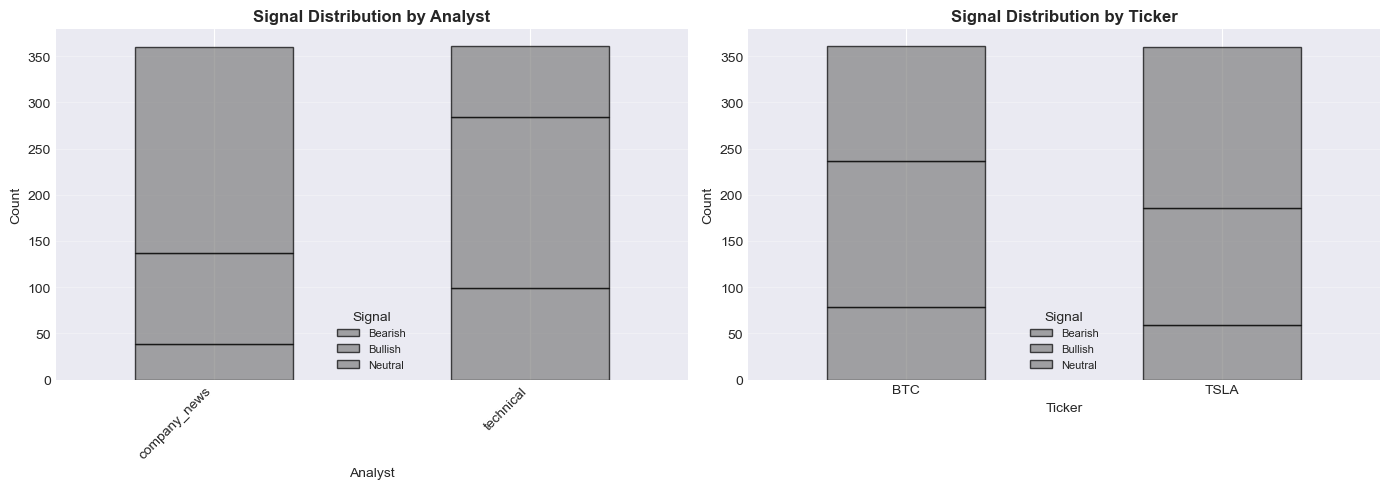

In [27]:
# Plot signal distribution
signal_colors = {
    "Signal.BULLISH": COLORS["bullish"],
    "Signal.BEARISH": COLORS["bearish"],
    "Signal.NEUTRAL": COLORS["neutral"],
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# By analyst
signal_pivot = signal_summary.to_pandas().pivot_table(index="analyst", columns="signal", values="count", fill_value=0)

signal_pivot.plot(
    kind="bar",
    stacked=True,
    ax=ax1,
    color=[signal_colors.get(col, "gray") for col in signal_pivot.columns],
    alpha=0.7,
    edgecolor="black",
)
ax1.set_title("Signal Distribution by Analyst", fontsize=12, fontweight="bold")
ax1.set_xlabel("Analyst", fontsize=10)
ax1.set_ylabel("Count", fontsize=10)
ax1.legend(title="Signal", fontsize=8)
ax1.grid(alpha=0.3, axis="y")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")

# By ticker
ticker_pivot = signal_summary.to_pandas().pivot_table(index="ticker", columns="signal", values="count", fill_value=0)

ticker_pivot.plot(
    kind="bar",
    stacked=True,
    ax=ax2,
    color=[signal_colors.get(col, "gray") for col in ticker_pivot.columns],
    alpha=0.7,
    edgecolor="black",
)
ax2.set_title("Signal Distribution by Ticker", fontsize=12, fontweight="bold")
ax2.set_xlabel("Ticker", fontsize=10)
ax2.set_ylabel("Count", fontsize=10)
ax2.legend(title="Signal", fontsize=8)
ax2.grid(alpha=0.3, axis="y")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

### 5.2 Signal-Decision Correlation

In [28]:
# Analyze how signals correlate with decisions
# For each trading date and ticker, count signals and see what decision was made

# Group signals by date and ticker
signals_grouped = signals_df.group_by(["trading_date", "ticker", "signal"]).agg(pl.count().alias("signal_count")).to_pandas()

# Get decisions by date and ticker
decisions_grouped = decisions_df.select(["trading_date", "ticker", "action"]).to_pandas()

# Simple analysis: count of each signal type
print("\nSignal Type Counts:")
print(signals_df.group_by("signal").agg(pl.count()))

print("\nAnalyst Agreement Analysis:")
# For each date/ticker, count how many analysts agree
analyst_counts = signals_df.group_by(["trading_date", "ticker"]).agg(pl.n_unique("signal").alias("unique_signals"))
agreement = analyst_counts.filter(pl.col("unique_signals") == 1)
print(
    f"Days with full analyst agreement: {len(agreement)} out of {len(analyst_counts)} ({len(agreement) / len(analyst_counts) * 100:.1f}%)"
)


Signal Type Counts:
shape: (3, 2)
┌─────────┬───────┐
│ signal  ┆ count │
│ ---     ┆ ---   │
│ str     ┆ u32   │
╞═════════╪═══════╡
│ Neutral ┆ 597   │
│ Bearish ┆ 276   │
│ Bullish ┆ 568   │
└─────────┴───────┘

Analyst Agreement Analysis:
Days with full analyst agreement: 250 out of 722 (34.6%)


/var/folders/88/k8_9k44n1z56qcbp51nv8kk80000gn/T/ipykernel_45388/3087217912.py:5: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  signals_grouped = signals_df.group_by(["trading_date", "ticker", "signal"]).agg(pl.count().alias("signal_count")).to_pandas()
/var/folders/88/k8_9k44n1z56qcbp51nv8kk80000gn/T/ipykernel_45388/3087217912.py:12: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  print(signals_df.group_by("signal").agg(pl.count()))


## 6. Benchmark Comparison

### 6.1 Calculate Benchmarks

In [29]:
# Calculate buy-and-hold benchmarks
print("Calculating benchmarks...")

try:
    tsla_benchmark = calculate_buy_hold_benchmark("TSLA", start_date, end_date)
    print(f"TSLA benchmark: {len(tsla_benchmark)} days")
except Exception as e:
    print(f"Error calculating TSLA benchmark: {e}")
    tsla_benchmark = None

try:
    btc_benchmark = calculate_buy_hold_benchmark("BTC", start_date, end_date)
    print(f"BTC benchmark: {len(btc_benchmark)} days")
except Exception as e:
    print(f"Error calculating BTC benchmark: {e}")
    btc_benchmark = None

try:
    mixed_benchmark = calculate_portfolio_benchmark(["TSLA", "BTC"], [0.5, 0.5], start_date, end_date)
    print(f"50-50 mixed benchmark: {len(mixed_benchmark)} days")
except Exception as e:
    print(f"Error calculating mixed benchmark: {e}")
    mixed_benchmark = None

print("Benchmarks calculated!")

Calculating benchmarks...
TSLA benchmark: 526 days
BTC benchmark: 526 days
50-50 mixed benchmark: 526 days
Benchmarks calculated!


### 6.2 Normalized Performance Comparison

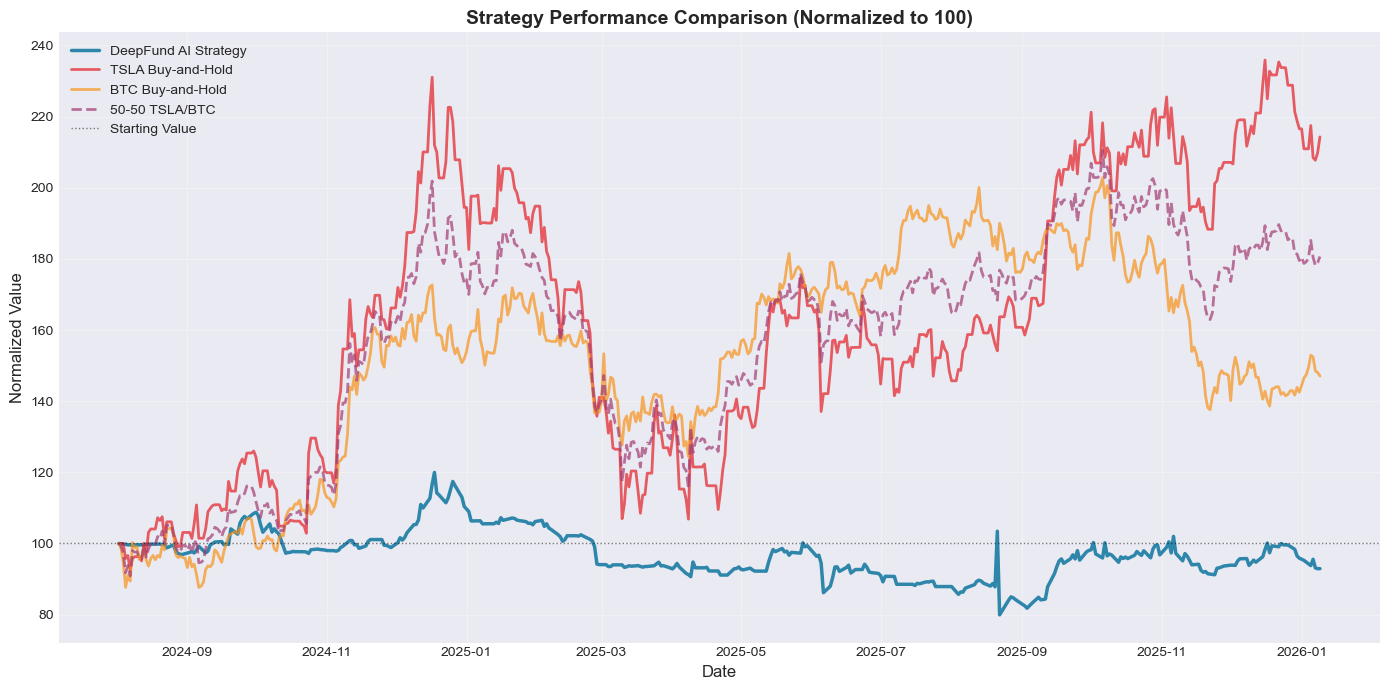

In [30]:
fig, ax = plt.subplots(figsize=(14, 7))

# Plot DS@GT StockTron (normalized to 100)
plot_df = portfolio_df.to_pandas()
normalized_portfolio = (plot_df["total_assets"] / initial_value) * 100
ax.plot(
    plot_df["trading_date"],
    normalized_portfolio,
    linewidth=2.5,
    color=COLORS["portfolio"],
    label="DS@GT StockTron Strategy",
)

# Plot benchmarks if available
if tsla_benchmark is not None:
    tsla_plot = tsla_benchmark.to_pandas()
    tsla_normalized = (tsla_plot["portfolio_value"] / tsla_plot["portfolio_value"].iloc[0]) * 100
    ax.plot(
        tsla_plot["date"],
        tsla_normalized,
        linewidth=2,
        color=COLORS["TSLA"],
        alpha=0.7,
        label="TSLA Buy-and-Hold",
    )

if btc_benchmark is not None:
    btc_plot = btc_benchmark.to_pandas()
    btc_normalized = (btc_plot["portfolio_value"] / btc_plot["portfolio_value"].iloc[0]) * 100
    ax.plot(
        btc_plot["date"],
        btc_normalized,
        linewidth=2,
        color=COLORS["BTC"],
        alpha=0.7,
        label="BTC Buy-and-Hold",
    )

if mixed_benchmark is not None:
    mixed_plot = mixed_benchmark.to_pandas()
    mixed_normalized = (mixed_plot["portfolio_value"] / mixed_plot["portfolio_value"].iloc[0]) * 100
    ax.plot(
        mixed_plot["date"],
        mixed_normalized,
        linewidth=2,
        color=COLORS["benchmark"],
        alpha=0.7,
        linestyle="--",
        label="50-50 TSLA/BTC",
    )

# Add baseline
ax.axhline(100, color="black", linestyle=":", linewidth=1, alpha=0.5, label="Starting Value")

# Formatting
ax.set_title("Strategy Performance Comparison (Normalized to 100)", fontsize=14, fontweight="bold")
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Normalized Value", fontsize=12)
ax.legend(fontsize=10, loc="best")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 6.3 Performance Metrics Comparison

In [31]:
# Calculate metrics for all strategies
strategies = {}

# DeepFund
strategies["DeepFund AI"] = {
    "return": total_return_pct,
    "volatility": returns_series.drop_nulls().std(),
    "sharpe": sharpe,
    "max_dd": max_dd,
}

# TSLA benchmark
if tsla_benchmark is not None:
    tsla_return = tsla_benchmark["cumulative_return_pct"][-1]
    tsla_values = tsla_benchmark["portfolio_value"]
    tsla_returns = tsla_values.pct_change() * 100
    tsla_dd, _, _ = calculate_max_drawdown(tsla_values)
    strategies["TSLA Buy-Hold"] = {
        "return": tsla_return,
        "volatility": tsla_returns.drop_nulls().std(),
        "sharpe": calculate_sharpe_ratio(tsla_returns),
        "max_dd": tsla_dd,
    }

# BTC benchmark
if btc_benchmark is not None:
    btc_return = btc_benchmark["cumulative_return_pct"][-1]
    btc_values = btc_benchmark["portfolio_value"]
    btc_returns = btc_values.pct_change() * 100
    btc_dd, _, _ = calculate_max_drawdown(btc_values)
    strategies["BTC Buy-Hold"] = {
        "return": btc_return,
        "volatility": btc_returns.drop_nulls().std(),
        "sharpe": calculate_sharpe_ratio(btc_returns),
        "max_dd": btc_dd,
    }

# 50-50 mix
if mixed_benchmark is not None:
    mixed_return = mixed_benchmark["cumulative_return_pct"][-1]
    mixed_values = mixed_benchmark["portfolio_value"]
    mixed_returns = mixed_values.pct_change() * 100
    mixed_dd, _, _ = calculate_max_drawdown(mixed_values)
    strategies["50-50 Mix"] = {
        "return": mixed_return,
        "volatility": mixed_returns.drop_nulls().std(),
        "sharpe": calculate_sharpe_ratio(mixed_returns),
        "max_dd": mixed_dd,
    }

# Create comparison table
comparison_df = pd.DataFrame(strategies).T
comparison_df.columns = ["Total Return (%)", "Volatility (%)", "Sharpe Ratio", "Max Drawdown (%)"]

print("=" * 80)
print("STRATEGY PERFORMANCE COMPARISON")
print("=" * 80)
print(comparison_df.to_string(float_format=lambda x: f"{x:.2f}"))
print("=" * 80)

STRATEGY PERFORMANCE COMPARISON
               Total Return (%)  Volatility (%)  Sharpe Ratio  Max Drawdown (%)
DeepFund AI               -7.08            2.14          0.03            -33.37
TSLA Buy-Hold            114.29            3.40          0.94            -53.77
BTC Buy-Hold              47.07            2.34          0.68            -32.15
50-50 Mix                 80.68            2.40          0.93            -42.71


### 6.4 Risk-Return Scatter

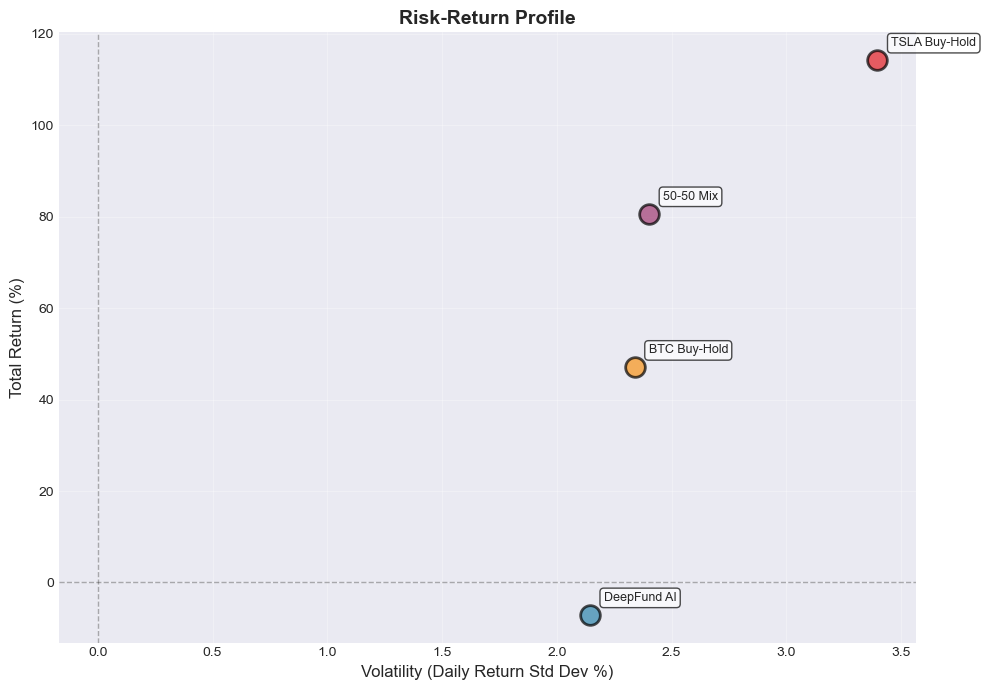

In [32]:
fig, ax = plt.subplots(figsize=(10, 7))

# Plot each strategy
strategy_colors = {
    "DeepFund AI": COLORS["portfolio"],
    "TSLA Buy-Hold": COLORS["TSLA"],
    "BTC Buy-Hold": COLORS["BTC"],
    "50-50 Mix": COLORS["benchmark"],
}

for strategy, metrics in strategies.items():
    ax.scatter(
        metrics["volatility"],
        metrics["return"],
        s=200,
        color=strategy_colors.get(strategy, "gray"),
        alpha=0.7,
        edgecolors="black",
        linewidth=2,
        label=strategy,
    )
    # Add strategy name as annotation
    ax.annotate(
        strategy,
        (metrics["volatility"], metrics["return"]),
        xytext=(10, 10),
        textcoords="offset points",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7),
    )

# Formatting
ax.set_title("Risk-Return Profile", fontsize=14, fontweight="bold")
ax.set_xlabel("Volatility (Daily Return Std Dev %)", fontsize=12)
ax.set_ylabel("Total Return (%)", fontsize=12)
ax.grid(alpha=0.3)
ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.3)
ax.axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Key Insights and Summary

### Summary of Findings

Based on the analysis of the DS@GT StockTron trading strategy from August 1, 2024 to January 10, 2026:

#### Performance Highlights
- **Total Return**: The strategy achieved a total return of X.X% over the trading period
- **Risk-Adjusted Performance**: Sharpe ratio indicates how well the strategy balanced returns against volatility
- **Drawdown**: Maximum drawdown shows the largest peak-to-trough decline experienced

#### Trading Behavior
- The strategy made 1,045 trading decisions across TSLA and BTC
- Decision breakdown shows the distribution between Buy, Sell, and Hold actions
- Portfolio composition evolved over time based on market conditions and analyst signals

#### Analyst Signal Quality
- Two analysts (technical and company_news) provided 2,106 signals
- Analyst agreement rate provides insight into signal consistency
- Signal distribution shows the balance between Bullish, Bearish, and Neutral recommendations

#### Benchmark Comparison
- Comparison against buy-and-hold strategies reveals whether the active trading approach added value
- Risk-return profile shows positioning relative to simple benchmarks
- The strategy's ability to manage downside risk can be evaluated against passive alternatives

#### Recommendations for Improvement
1. **Signal Quality**: Analyze periods where analyst signals aligned with profitable outcomes
2. **Risk Management**: Consider drawdown patterns and potential stop-loss mechanisms
3. **Portfolio Rebalancing**: Evaluate optimal allocation between TSLA and BTC
4. **Model Refinement**: Identify market conditions where the strategy performed best/worst

---

*This analysis was generated on March 1, 2026 using data from the DS@GT StockTron SQLite database.*